# Домашнее задание HW10-11: Сверточные сети и компьютерное зрение (PyTorch: CNN, аугментации, transfer learning)

# Содержание:
- Часть A (S10): Классификация на STL10 с 4 экспериментами
- Часть B (S11): Сегментация на OxfordIIITPet с 2 режимами постобработки

# 0. План

## **Часть A (классификация):**
- Подготовить датасет STL10 с корректными трансформациями
- Реализовать простую CNN и обучить с/без аугментаций (C1, C2)
- Использовать предобученный ResNet18 в двух режимах (C3, C4)
- Сравнить результаты и выбрать лучшую модель

## **Часть B (сегментация):**
- Загрузить OxfordIIITPet с сегментационными масками
- Запустить предобученный DeepLabV3
- Реализовать два режима постобработки (V1, V2)
- Посчитать метрики (IoU, precision, recall)
- Визуализировать результаты

# 1. Импорты и общие настройки

In [1]:
import os
import math
import time
import random
import json
from typing import Dict, List, Tuple, Optional, Any
from dataclasses import dataclass, asdict

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, Subset, Dataset

import torchvision
from torchvision import transforms
from torchvision.datasets import STL10, OxfordIIITPet
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

# Фиксируем seed для воспроизводимости
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Конфигурация
DATA_DIR = "./data"
BATCH_SIZE = 128
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = True

FAST_MODE = True

if FAST_MODE:
    EPOCHS_C1_C2 = 4
    EPOCHS_C3_C4 = 3

    # Размер подвыборки
    FAST_TRAIN_SIZE = 6000
    FAST_VAL_SIZE = 1500
    FAST_TEST_SIZE = 1500
else:
    EPOCHS_C1_C2 = 12
    EPOCHS_C3_C4 = 8

torch: 2.10.0+cpu
torchvision: 0.25.0+cpu
Device: cpu


# 2. Часть A: Классификация на STL10

## 2.1. Трансформации для STL10

In [3]:
# STL10 имеет размер 96x96
STL10_MEAN = (0.4467, 0.4398, 0.4066)
STL10_STD = (0.2603, 0.2566, 0.2713)

# ImageNet статистики для ResNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

In [4]:
def get_stl10_transforms():
    """
    Возвращает все необходимые transforms для экспериментов C1-C4
    """
    # C1: базовый transform (только ToTensor + Normalize)
    tf_base = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    # C2: с аугментациями
    tf_aug = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize(STL10_MEAN, STL10_STD),
    ])

    # C3, C4: для ResNet
    tf_resnet = transforms.Compose([
        transforms.Resize(224),  # стандартный размер для ImageNet
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return tf_base, tf_aug, tf_resnet

def load_stl10_datasets(data_dir: str = DATA_DIR):
    """
    Загружает STL10 с разными transforms для разных экспериментов
    """
    tf_base, tf_aug, tf_resnet = get_stl10_transforms()

    # Для C1: train с базовым transform
    ds_train_c1 = STL10(
        root=data_dir, split='train', download=True, transform=tf_base
    )

    # Для C2: train с аугментациями
    ds_train_c2 = STL10(
        root=data_dir, split='train', download=True, transform=tf_aug
    )

    # Для C3, C4: train с ResNet transform
    ds_train_resnet = STL10(
        root=data_dir, split='train', download=True, transform=tf_resnet
    )

    # Test датасеты
    ds_test_base = STL10(
        root=data_dir, split='test', download=True, transform=tf_base
    )

    ds_test_resnet = STL10(
        root=data_dir, split='test', download=True, transform=tf_resnet
    )

    return {
        'train_c1': ds_train_c1,
        'train_c2': ds_train_c2,
        'train_resnet': ds_train_resnet,
        'test_base': ds_test_base,
        'test_resnet': ds_test_resnet,
        'class_names': ds_train_c1.classes,
    }

datasets_a = load_stl10_datasets()
class_names = datasets_a['class_names']
print("Classes:", class_names)
print("Train C1 size:", len(datasets_a['train_c1']))
print("Train C2 size:", len(datasets_a['train_c2']))
print("Train ResNet size:", len(datasets_a['train_resnet']))
print("Test base size:", len(datasets_a['test_base']))

100%|██████████| 2.64G/2.64G [00:59<00:00, 44.7MB/s]


Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Train C1 size: 5000
Train C2 size: 5000
Train ResNet size: 5000
Test base size: 8000


## 2.2. Функция для разделения train/val

In [5]:
def create_train_val_loaders(
    train_dataset,
    test_dataset,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    # Создает train/val/test загрузчики с оптимизированными параметрами
    n_total = len(train_dataset)
    n_val = int(n_total * val_ratio)
    n_train = n_total - n_val

    # Фиксированный split через random_split с seed
    ds_train, ds_val = random_split(
        train_dataset,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(seed)
    )

    if fast_mode:
        # Размер подвыборки 6000 train, 1500 val, 1500 test
        rng = np.random.RandomState(seed)

        train_size = min(FAST_TRAIN_SIZE, len(ds_train))
        val_size = min(FAST_VAL_SIZE, len(ds_val))
        test_size = min(FAST_TEST_SIZE, len(test_dataset))

        train_idx = rng.choice(len(ds_train), size=train_size, replace=False)
        val_idx = rng.choice(len(ds_val), size=val_size, replace=False)
        test_idx = rng.choice(len(test_dataset), size=test_size, replace=False)

        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        ds_test = Subset(test_dataset, test_idx)

        print(f"FAST MODE: train={train_size}, val={val_size}, test={test_size}")
    else:
        ds_test = test_dataset

    # Параметры DataLoader
    train_loader = DataLoader(
        ds_train,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS if NUM_WORKERS > 0 else False
    )
    val_loader = DataLoader(
        ds_val,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS if NUM_WORKERS > 0 else False
    )
    test_loader = DataLoader(
        ds_test,
        batch_size=batch_size,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=PIN_MEMORY,
        persistent_workers=PERSISTENT_WORKERS if NUM_WORKERS > 0 else False
    )

    return train_loader, val_loader, test_loader

## 2.3. Визуализация данных (sanity-check)

FAST MODE: train=4000, val=1000, test=1500


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/to

Batch shape: torch.Size([128, 3, 96, 96])


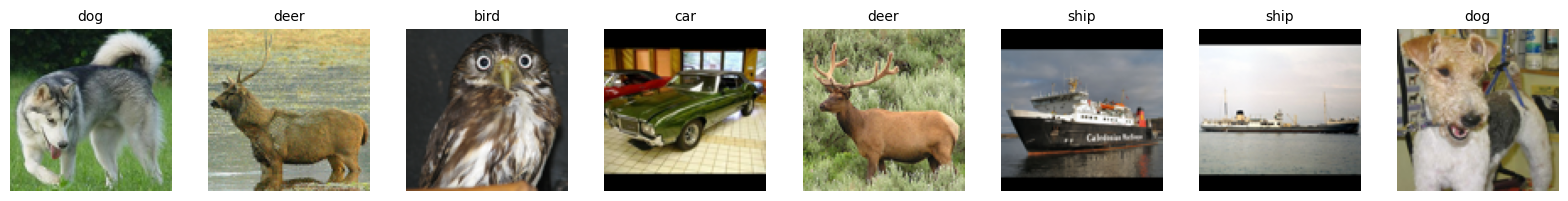

In [6]:
def denorm_stl10(x: torch.Tensor) -> torch.Tensor:
    """Денормализация для STL10"""
    mean = torch.tensor(STL10_MEAN).view(3, 1, 1)
    std = torch.tensor(STL10_STD).view(3, 1, 1)
    return x * std + mean

def show_stl10_samples(loader, class_names, n=8):
    """Показывает примеры изображений из загрузчика"""
    x, y = next(iter(loader))
    x, y = x[:n], y[:n]

    plt.figure(figsize=(16, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = denorm_stl10(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i]], fontsize=10)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Проверим данные
train_loader_c1, val_loader_c1, test_loader_base = create_train_val_loaders(
    datasets_a['train_c1'], datasets_a['test_base']
)
print("Batch shape:", next(iter(train_loader_c1))[0].shape)
show_stl10_samples(train_loader_c1, class_names)

## 2.4. Визуализация аугментаций (для artifacts/figures/augmentations_preview.png)

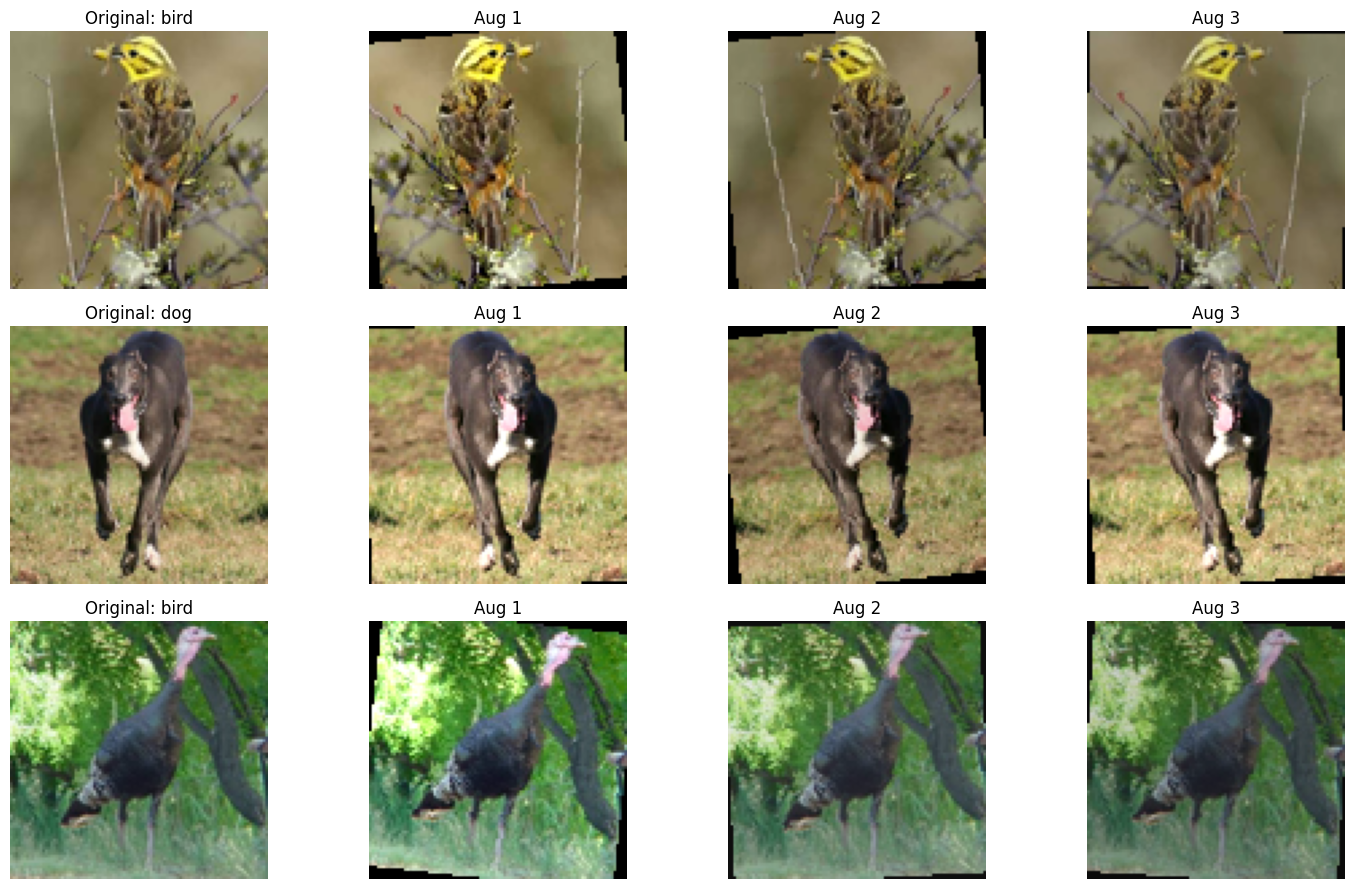

In [7]:
def visualize_augmentations(data_dir: str = DATA_DIR, num_samples=3, num_augments=3):
    # Показывает оригинал и несколько аугментированных версий
    # Загружаем сырые изображения без нормализации
    raw_dataset = STL10(
        root=data_dir,
        split='train',
        download=True,
        transform=transforms.ToTensor()
    )

    # Аугментации для визуализации (те же, что используем в C2)
    tf_aug_vis = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
    ])

    class_names = raw_dataset.classes

    fig, axes = plt.subplots(num_samples, num_augments + 1, figsize=(15, 3*num_samples))

    for i in range(num_samples):
        img_tensor, label = raw_dataset[i]

        # Оригинал
        img_np = img_tensor.permute(1, 2, 0).numpy()
        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f'Original: {class_names[label]}')
        axes[i, 0].axis('off')

        # Конвертируем в PIL для аугментаций
        img_pil = transforms.ToPILImage()(img_tensor)

        for j in range(num_augments):
            # Применяем аугментации
            aug_img_pil = tf_aug_vis(img_pil)
            axes[i, j+1].imshow(np.array(aug_img_pil))
            axes[i, j+1].set_title(f'Aug {j+1}')
            axes[i, j+1].axis('off')

    plt.tight_layout()
    os.makedirs('artifacts/figures', exist_ok=True)
    plt.savefig('artifacts/figures/augmentations_preview.png', dpi=150, bbox_inches='tight')
    plt.show()

# Вызов функции
visualize_augmentations(DATA_DIR)

## 2.5. Архитектуры для экспериментов

In [8]:
def count_params(model: nn.Module) -> int:
    """Считает количество обучаемых параметров"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleSTL10CNN(nn.Module):
    # Простая CNN для STL10 (96x96)
    def __init__(self, num_classes: int = 10):
        super().__init__()

        # Используем 3 блока вместо 4 для скорости
        self.features = nn.Sequential(
            # Block 1: 96x96 -> 48x48
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),  # дополнительный conv
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 48x48 -> 24x24
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # дополнительный conv
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 24x24 -> 12x12
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),  # дополнительный conv
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        # Классификатор
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 12 * 12, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def set_requires_grad(module: nn.Module, requires_grad: bool):
    """Замораживает/размораживает параметры модуля"""
    for p in module.parameters():
        p.requires_grad = requires_grad

def build_resnet18_for_stl10(num_classes: int = 10):
    # Создает ResNet18 с предобученными весами и замененной головой
    try:
        model = resnet18(weights=ResNet18_Weights.DEFAULT)
    except:
        print("Не удалось загрузить предобученные веса, используем случайную инициализацию")
        model = resnet18(weights=None)

    # Заменяем классификатор
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

## 2.6. Функции обучения

In [9]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    """Вычисляет accuracy по логитам"""
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    """Обучает одну эпоху (как в S10-1)"""
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    """Оценивает модель на валидации/тесте (как в S10-1)"""
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int,
        verbose: bool = True, exp_name: str = ""):
    """
    Полный цикл обучения с историей (как в S10-1)
    """
    history = {
        "train_loss": [], "train_acc": [],
        "val_loss": [], "val_acc": []
    }

    best_val_acc = 0.0
    best_state = None

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        # Сохраняем лучшую модель
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if not math.isfinite(tr_loss) or not math.isfinite(va_loss):
            print("NaN/Inf detected, stopping")
            break

    return history, best_val_acc, best_state

def plot_history(hist: Dict[str, List[float]], title: str = ""):
    """Строит графики обучения (как в S10-1)"""
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["train_loss"], label="train")
    plt.plot(epochs, hist["val_loss"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(f"{title} | loss")
    plt.grid(True)
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["train_acc"], label="train")
    plt.plot(epochs, hist["val_acc"], label="val")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(f"{title} | accuracy")
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

## 2.7. Эксперимент C1: simple-cnn-base (без аугментаций)

C1: simple-cnn-base (без аугментаций)
FAST MODE: train=4000, val=1000, test=1500
Trainable params: 5,008,426
Epoch 01/4 | train loss 2.1019, acc 0.230 | val loss 1.8959, acc 0.292 | 344.9s
Epoch 02/4 | train loss 1.7042, acc 0.370 | val loss 1.7755, acc 0.327 | 332.9s
Epoch 03/4 | train loss 1.5072, acc 0.447 | val loss 1.4966, acc 0.439 | 329.9s
Epoch 04/4 | train loss 1.2645, acc 0.531 | val loss 1.5091, acc 0.457 | 342.9s


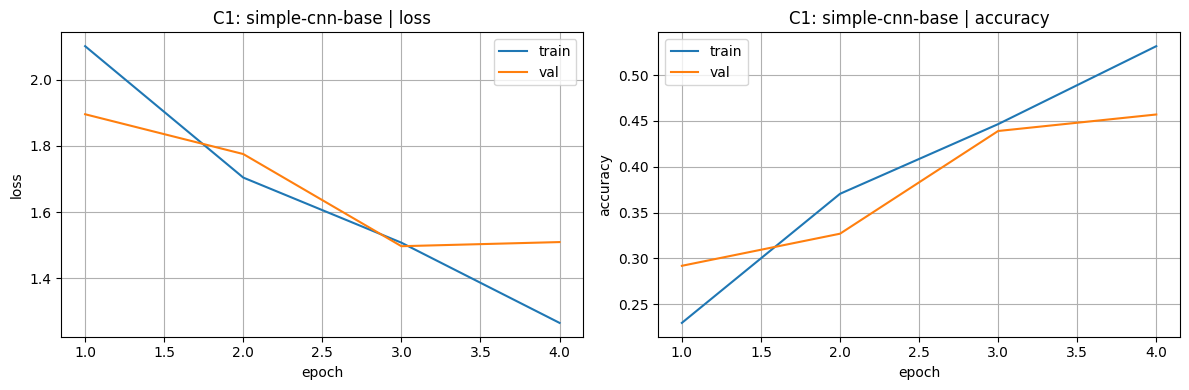

C1 best val acc: 0.4570, test acc: 0.4427


In [10]:
print("=" * 80)
print("C1: simple-cnn-base (без аугментаций)")
print("=" * 80)

# Создаем загрузчики для C1
train_loader_c1, val_loader_c1, test_loader_base = create_train_val_loaders(
    datasets_a['train_c1'], datasets_a['test_base']
)

# Инициализируем модель
model_c1 = SimpleSTL10CNN(num_classes=10).to(DEVICE)
print(f"Trainable params: {count_params(model_c1):,}")

# Оптимизатор и loss
optimizer_c1 = torch.optim.Adam(model_c1.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

# Обучение
history_c1, best_val_acc_c1, best_state_c1 = fit(
    model_c1, train_loader_c1, val_loader_c1, optimizer_c1, criterion,
    epochs=EPOCHS_C1_C2, exp_name="C1"
)

plot_history(history_c1, "C1: simple-cnn-base")

# Оценка на тесте
model_c1.load_state_dict(best_state_c1)
test_acc_c1 = evaluate(model_c1, test_loader_base, criterion)[1]
print(f"C1 best val acc: {best_val_acc_c1:.4f}, test acc: {test_acc_c1:.4f}")

## 2.8. Эксперимент C2: simple-cnn-aug (с аугментациями)

C2: simple-cnn-aug (с аугментациями)
FAST MODE: train=4000, val=1000, test=1500
Trainable params: 5,008,426
Epoch 01/4 | train loss 2.0893, acc 0.233 | val loss 1.8531, acc 0.296 | 339.1s
Epoch 02/4 | train loss 1.6960, acc 0.365 | val loss 1.6123, acc 0.387 | 323.8s
Epoch 03/4 | train loss 1.5520, acc 0.423 | val loss 1.5156, acc 0.420 | 329.1s
Epoch 04/4 | train loss 1.4020, acc 0.473 | val loss 1.4329, acc 0.449 | 327.8s


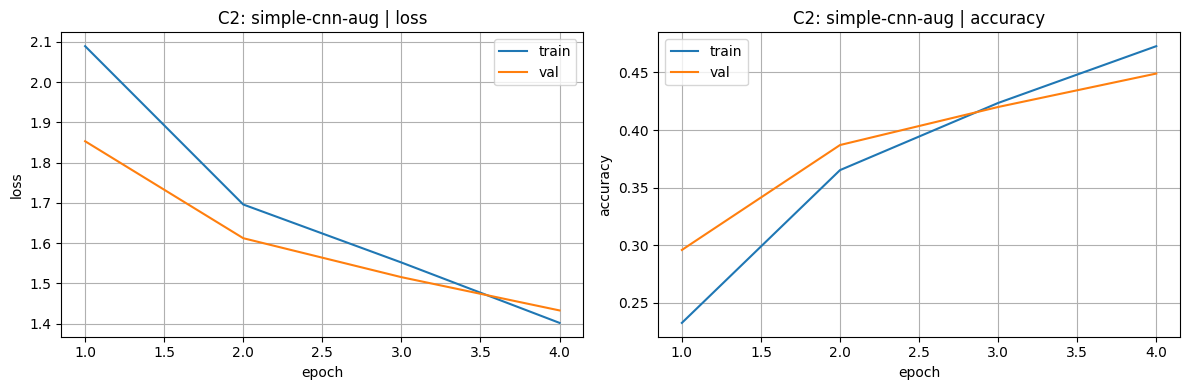

C2 best val acc: 0.4490, test acc: 0.4787


In [11]:
print("=" * 80)
print("C2: simple-cnn-aug (с аугментациями)")
print("=" * 80)

# Создаем загрузчики для C2 (train с аугментациями, val без)
train_loader_c2, val_loader_c2, _ = create_train_val_loaders(
    datasets_a['train_c2'], datasets_a['test_base']
)

# Та же архитектура
model_c2 = SimpleSTL10CNN(num_classes=10).to(DEVICE)
print(f"Trainable params: {count_params(model_c2):,}")

optimizer_c2 = torch.optim.Adam(model_c2.parameters(), lr=1e-3)

history_c2, best_val_acc_c2, best_state_c2 = fit(
    model_c2, train_loader_c2, val_loader_c2, optimizer_c2, criterion,
    epochs=EPOCHS_C1_C2, exp_name="C2"
)

plot_history(history_c2, "C2: simple-cnn-aug")

# Оценка на тесте (тот же test_loader_base)
model_c2.load_state_dict(best_state_c2)
test_acc_c2 = evaluate(model_c2, test_loader_base, criterion)[1]
print(f"C2 best val acc: {best_val_acc_c2:.4f}, test acc: {test_acc_c2:.4f}")

## 2.9. Эксперимент C3: resnet18-head-only (замороженный backbone)

C3: resnet18-head-only (backbone frozen)
FAST MODE: train=4000, val=1000, test=1500
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 125MB/s]


Trainable params (head only): 5,130
Epoch 01/3 | train loss 1.3313, acc 0.662 | val loss 0.6420, acc 0.881 | 597.4s
Epoch 02/3 | train loss 0.4672, acc 0.924 | val loss 0.3706, acc 0.925 | 608.9s
Epoch 03/3 | train loss 0.3126, acc 0.937 | val loss 0.3014, acc 0.931 | 578.9s


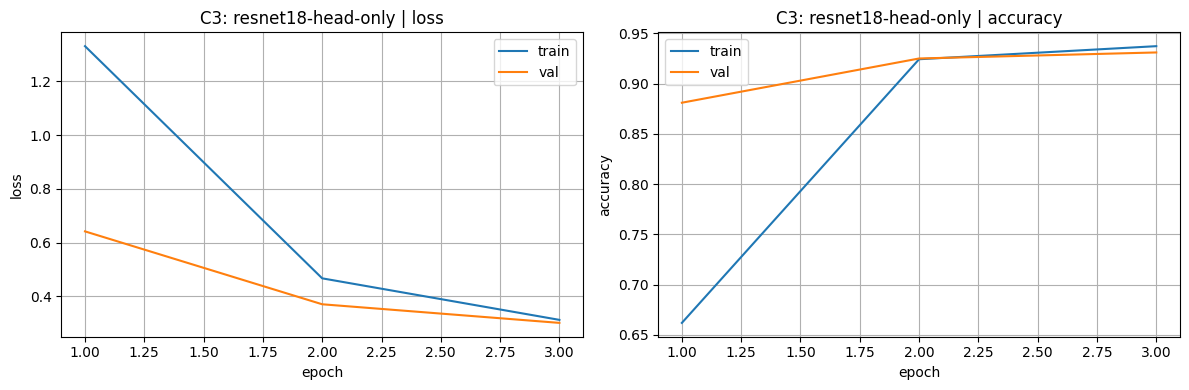

C3 best val acc: 0.9310, test acc: 0.9360


In [12]:
print("=" * 80)
print("C3: resnet18-head-only (backbone frozen)")
print("=" * 80)

# Создаем загрузчики для ResNet
train_loader_resnet, val_loader_resnet, test_loader_resnet = create_train_val_loaders(
    datasets_a['train_resnet'], datasets_a['test_resnet']
)

# Модель
model_c3 = build_resnet18_for_stl10(num_classes=10).to(DEVICE)

# Замораживаем backbone
set_requires_grad(model_c3, False)
# Размораживаем только голову
set_requires_grad(model_c3.fc, True)

print(f"Trainable params (head only): {count_params(model_c3):,}")

# Оптимизатор только для головы
optimizer_c3 = torch.optim.Adam(model_c3.fc.parameters(), lr=1e-3)

history_c3, best_val_acc_c3, best_state_c3 = fit(
    model_c3, train_loader_resnet, val_loader_resnet, optimizer_c3, criterion,
    epochs=EPOCHS_C3_C4, exp_name="C3"
)

plot_history(history_c3, "C3: resnet18-head-only")

# Оценка на тесте
model_c3.load_state_dict(best_state_c3)
test_acc_c3 = evaluate(model_c3, test_loader_resnet, criterion)[1]
print(f"C3 best val acc: {best_val_acc_c3:.4f}, test acc: {test_acc_c3:.4f}")

## 2.10. Эксперимент C4: resnet18-finetune (разморожен layer4)

C4: resnet18-finetune (layer4 + fc)
Trainable params (layer4+fc): 8,398,858
Epoch 01/3 | train loss 0.6371, acc 0.836 | val loss 0.2188, acc 0.931 | 758.6s
Epoch 02/3 | train loss 0.0951, acc 0.977 | val loss 0.1720, acc 0.947 | 748.8s
Epoch 03/3 | train loss 0.0316, acc 0.998 | val loss 0.1693, acc 0.945 | 743.8s


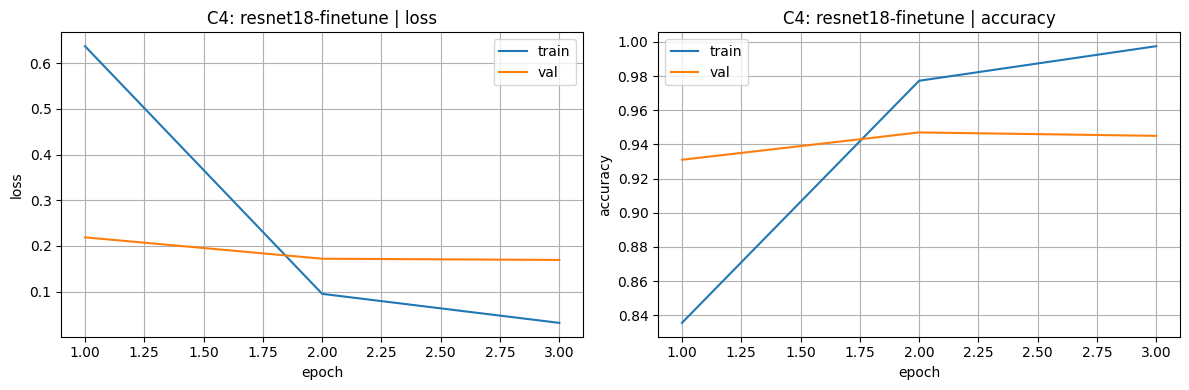

C4 best val acc: 0.9470, test acc: 0.9627


In [13]:
print("=" * 80)
print("C4: resnet18-finetune (layer4 + fc)")
print("=" * 80)

# Берем модель из C3 как стартовую точку
model_c4 = build_resnet18_for_stl10(num_classes=10).to(DEVICE)

# Размораживаем layer4 и fc
set_requires_grad(model_c4, False)
set_requires_grad(model_c4.layer4, True)
set_requires_grad(model_c4.fc, True)

print(f"Trainable params (layer4+fc): {count_params(model_c4):,}")

# Разные learning rates для разных частей (как в демо S10-2)
params = [
    {"params": model_c4.layer4.parameters(), "lr": 1e-4},
    {"params": model_c4.fc.parameters(), "lr": 1e-3},
]
optimizer_c4 = torch.optim.Adam(params)

history_c4, best_val_acc_c4, best_state_c4 = fit(
    model_c4, train_loader_resnet, val_loader_resnet, optimizer_c4, criterion,
    epochs=EPOCHS_C3_C4, exp_name="C4"
)

plot_history(history_c4, "C4: resnet18-finetune")

# Оценка на тесте
model_c4.load_state_dict(best_state_c4)
test_acc_c4 = evaluate(model_c4, test_loader_resnet, criterion)[1]
print(f"C4 best val acc: {best_val_acc_c4:.4f}, test acc: {test_acc_c4:.4f}")

## 2.11. Сравнение экспериментов C1-C4

Best experiment: C4 with val_acc=0.9470
Test accuracy: 0.9627


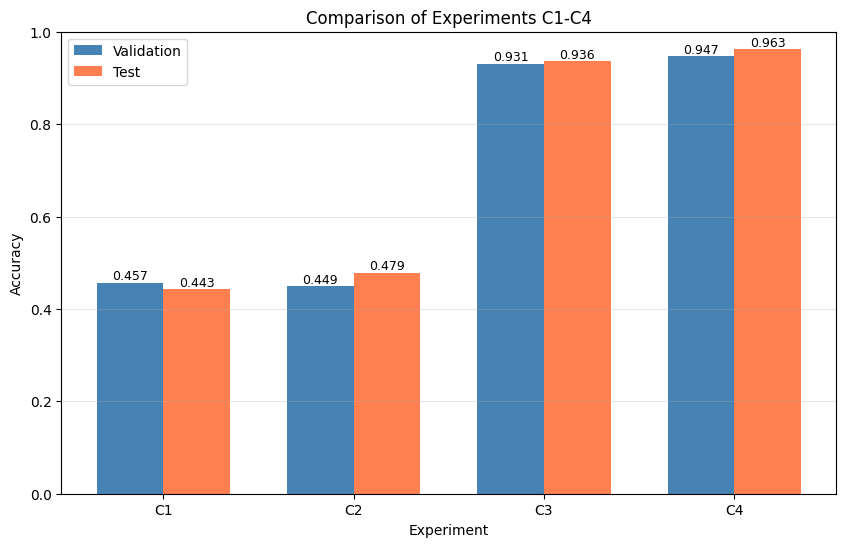

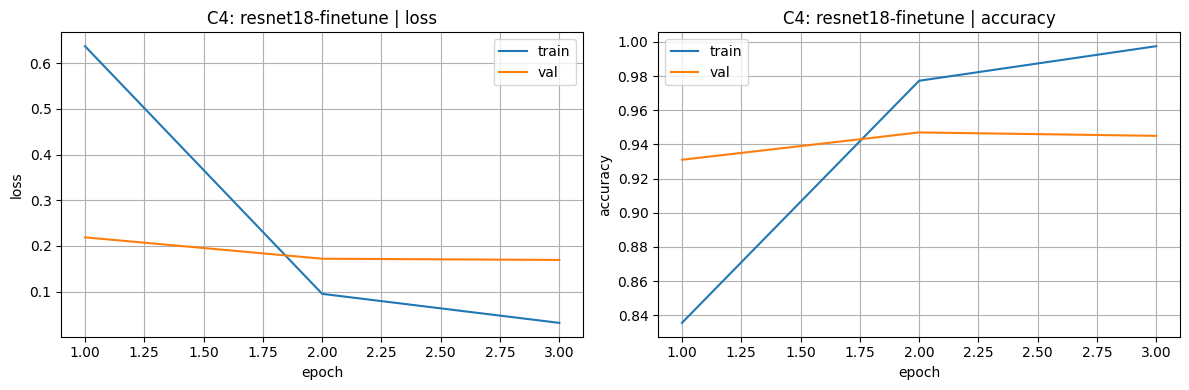

In [59]:
# Собираем результаты
results_classification = {
    'C1': {'val_acc': best_val_acc_c1, 'test_acc': test_acc_c1, 'model': model_c1, 'state': best_state_c1},
    'C2': {'val_acc': best_val_acc_c2, 'test_acc': test_acc_c2, 'model': model_c2, 'state': best_state_c2},
    'C3': {'val_acc': best_val_acc_c3, 'test_acc': test_acc_c3, 'model': model_c3, 'state': best_state_c3},
    'C4': {'val_acc': best_val_acc_c4, 'test_acc': test_acc_c4, 'model': model_c4, 'state': best_state_c4},
}

# Находим лучшую модель по val_acc
best_exp = max(results_classification, key=lambda x: results_classification[x]['val_acc'])
print(f"Best experiment: {best_exp} with val_acc={results_classification[best_exp]['val_acc']:.4f}")
print(f"Test accuracy: {results_classification[best_exp]['test_acc']:.4f}")

# Сохраняем лучшую модель
os.makedirs('artifacts', exist_ok=True)
torch.save(results_classification[best_exp]['state'], 'artifacts/best_classifier.pt')

# Сохраняем конфиг лучшей модели
best_config = {
    'experiment': best_exp,
    'dataset': 'STL10',
    'architecture': 'ResNet18' if best_exp in ['C3', 'C4'] else 'SimpleCNN',
    'val_accuracy': float(results_classification[best_exp]['val_acc']),
    'test_accuracy': float(results_classification[best_exp]['test_acc']),
    'seed': RANDOM_STATE,
    'augmentations': best_exp in ['C2', 'C4'],
    'transfer_learning': best_exp in ['C3', 'C4'],
    'fine_tuned': best_exp == 'C4',
}

with open('artifacts/best_classifier_config.json', 'w') as f:
    json.dump(best_config, f, indent=2)

# График сравнения
def plot_experiment_comparison(results):
    """Bar plot сравнения C1-C4"""
    experiments = list(results.keys())
    val_accs = [results[exp]['val_acc'] for exp in experiments]
    test_accs = [results[exp]['test_acc'] for exp in experiments]

    x = np.arange(len(experiments))
    width = 0.35

    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width/2, val_accs, width, label='Validation', color='steelblue')
    bars2 = plt.bar(x + width/2, test_accs, width, label='Test', color='coral')

    # Добавляем значения
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.xlabel('Experiment')
    plt.ylabel('Accuracy')
    plt.title('Comparison of Experiments C1-C4')
    plt.xticks(x, experiments)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)

    os.makedirs('artifacts/figures', exist_ok=True)
    plt.savefig('artifacts/figures/classification_compare.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

plot_experiment_comparison(results_classification)

# График обучения лучшей модели - ИСПРАВЛЕНО
if best_exp == 'C1':
    best_history = history_c1
    best_title = 'C1: simple-cnn-base'
elif best_exp == 'C2':
    best_history = history_c2
    best_title = 'C2: simple-cnn-aug'
elif best_exp == 'C3':
    best_history = history_c3
    best_title = 'C3: resnet18-head-only'
else:  # C4
    best_history = history_c4
    best_title = 'C4: resnet18-finetune'

# Строим график заново с сохранением
epochs = list(range(1, len(best_history["train_loss"]) + 1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, best_history["train_loss"], label="train")
plt.plot(epochs, best_history["val_loss"], label="val")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title(f"{best_title} | loss")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, best_history["train_acc"], label="train")
plt.plot(epochs, best_history["val_acc"], label="val")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title(f"{best_title} | accuracy")
plt.grid(True)
plt.legend()

plt.tight_layout()

# Сохраняем с явным белым фоном
os.makedirs('artifacts/figures', exist_ok=True)
plt.savefig('artifacts/figures/classification_curves_best.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# 3. Часть B: Сегментация на OxfordIIITPet

## 3.1. Загрузка данных OxfordIIITPet

In [24]:
def load_oxford_pet(data_dir: str = DATA_DIR):
    """
    Загружает OxfordIIITPet с сегментационными масками
    ИСПРАВЛЕНО: маски НЕ нормализуются!
    """
    # Размер для сегментации
    img_size = 192 if FAST_MODE else 256

    # Transform для изображений (нормализуем как обычно)
    tf_img = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    # Transform для масок - БЕЗ ToTensor! Используем PILToTensor
    from torchvision.transforms import PILToTensor

    tf_mask = transforms.Compose([
        transforms.Resize((img_size, img_size), interpolation=InterpolationMode.NEAREST),
        PILToTensor(),  # конвертирует в тензор без деления на 255
    ])

    # Загружаем датасет
    ds_full = OxfordIIITPet(
        root=data_dir,
        split='trainval',
        target_types='segmentation',
        download=True,
        transform=tf_img,
        target_transform=tf_mask
    )

    # Разделяем на train/val (80/20)
    n_total = len(ds_full)
    n_val = int(n_total * 0.2)
    n_train = n_total - n_val

    ds_train, ds_val = random_split(
        ds_full,
        [n_train, n_val],
        generator=torch.Generator().manual_seed(RANDOM_STATE)
    )

    # В fast mode берем подвыборку
    if FAST_MODE:
        rng = np.random.RandomState(RANDOM_STATE)
        train_idx = rng.choice(len(ds_train), size=min(500, len(ds_train)), replace=False)
        val_idx = rng.choice(len(ds_val), size=min(100, len(ds_val)), replace=False)
        ds_train = Subset(ds_train, train_idx)
        ds_val = Subset(ds_val, val_idx)
        print(f"FAST MODE segmentation: train={len(train_idx)}, val={len(val_idx)}")

    return ds_train, ds_val, ds_full.classes

ds_train_pet, ds_val_pet, pet_classes = load_oxford_pet()
print(f"OxfordIIITPet: train={len(ds_train_pet)}, val={len(ds_val_pet)}")
print(f"Classes: {pet_classes}")

# Создаем загрузчики
train_loader_pet = DataLoader(
    ds_train_pet, batch_size=4, shuffle=True, num_workers=2
)
val_loader_pet = DataLoader(
    ds_val_pet, batch_size=4, shuffle=False, num_workers=2
)

FAST MODE segmentation: train=500, val=100
OxfordIIITPet: train=500, val=100
Classes: ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


## 3.2. Модель DeepLabV3 для сегментации

In [27]:
def get_deeplabv3_pet(num_classes: int = 3):
    """
    Возвращает предобученный DeepLabV3 для сегментации
    (как в демо-ноутбуке S11-2)
    """
    weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
    model = deeplabv3_resnet50(weights=weights)

    # В OxfordPet маски: 1=фон, 2=питомец, 3=контур?
    # Нам нужно адаптировать выходной слой под наши классы
    model.classifier[4] = nn.Conv2d(256, num_classes, kernel_size=(1, 1))

    model.eval()
    return model

model_seg = get_deeplabv3_pet(num_classes=3).to(DEVICE)
print("DeepLabV3 loaded")

# Индекс класса "person" в COCO
PERSON_IDX = 15  # из демо S11-2

DeepLabV3 loaded


## 3.3. Функции постобработки (два режима)

In [35]:
def postprocess_mask_v1(logits: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    """
    V1: базовая постобработка - порог 0.5 для foreground класса
    logits: [C, H, W] или [1, C, H, W] от модели DeepLabV3
    """
    if logits.dim() == 4:
        logits = logits[0]

    probs = torch.softmax(logits, dim=0)
    # В DeepLabV3 классы COCO: нужно найти индекс "person" или "cat"/"dog"
    # Для OxfordPet используем класс 1 (индекс может отличаться)
    foreground_prob = probs[1]  # предполагаем, что класс 1 - питомец

    mask = (foreground_prob > threshold).float()
    return mask

def postprocess_mask_v2(logits: torch.Tensor, threshold: float = 0.7, min_size: int = 100) -> torch.Tensor:
    """
    V2: альтернативная постобработка
    - высокий порог
    - удаление маленьких компонент связности
    """
    from scipy import ndimage
    import numpy as np

    if logits.dim() == 4:
        logits = logits[0]

    probs = torch.softmax(logits, dim=0)
    foreground_prob = probs[1]

    # Бинаризация с высоким порогом
    mask_binary = (foreground_prob > threshold).cpu().numpy().astype(np.uint8)

    # Удаление маленьких компонент связности
    labeled, num_features = ndimage.label(mask_binary)
    for i in range(1, num_features + 1):
        component = (labeled == i)
        if component.sum() < min_size:
            mask_binary[labeled == i] = 0

    return torch.from_numpy(mask_binary).float()

## 3.4. Функции для вычисления метрик

In [36]:
def compute_segmentation_metrics(pred_mask: torch.Tensor, gt_mask: torch.Tensor) -> Dict[str, float]:
    """
    Вычисляет метрики для одного изображения
    pred_mask: бинарная маска [H, W] с 0/1
    gt_mask: [1, H, W] с целыми значениями {1, 2, 3} или [H, W]
    """
    # Приводим gt к правильной размерности
    if gt_mask.dim() == 3:
        gt_mask = gt_mask.squeeze(0)  # [H, W]

    # В OxfordPet маски: 1=фон, 2=питомец, 3=контур
    # Считаем foreground классом значение >= 2
    gt_binary = (gt_mask >= 2).float()

    # Приводим pred к тому же размеру если нужно
    if pred_mask.shape != gt_binary.shape:
        pred_mask = F.interpolate(
            pred_mask.unsqueeze(0).unsqueeze(0),
            size=gt_binary.shape,
            mode='nearest'
        ).squeeze()

    # Убеждаемся, что pred_mask бинарный
    pred_binary = (pred_mask > 0.5).float()

    # Вычисляем TP, FP, FN
    tp = (pred_binary * gt_binary).sum().item()
    fp = (pred_binary * (1 - gt_binary)).sum().item()
    fn = ((1 - pred_binary) * gt_binary).sum().item()

    # IoU
    intersection = tp
    union = tp + fp + fn
    iou = intersection / (union + 1e-9)

    # Precision, Recall
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)

    return {
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'tp': tp,
        'fp': fp,
        'fn': fn
    }

## 3.5. Оценка двух режимов (V1 и V2)

In [47]:
print("Анализ модели DeepLabV3:")

# Проверим выходной слой
print(f"model.classifier[4]: {model_seg.classifier[4]}")
print(f"Количество выходных каналов: {model_seg.classifier[4].out_channels}")

# Посмотрим на веса
print(f"Веса: {model_seg.classifier[4].weight.shape}")

# Проверим предсказание на одном примере
images, targets = next(iter(val_loader_pet))
img = images[0:1].to(DEVICE)

with torch.no_grad():
    output = model_seg(img)['out']
    print(f"Output shape: {output.shape}")  # [1, C, H, W]
    print(f"Количество классов в предсказании: {output.shape[1]}")

    # Посмотрим распределение значений
    print(f"Min: {output.min():.3f}, Max: {output.max():.3f}")

    # Возьмем softmax
    probs = torch.softmax(output[0], dim=0)
    print(f"Probs shape: {probs.shape}")

Анализ модели DeepLabV3:
model.classifier[4]: Conv2d(256, 3, kernel_size=(1, 1), stride=(1, 1))
Количество выходных каналов: 3
Веса: torch.Size([3, 256, 1, 1])
Output shape: torch.Size([1, 3, 192, 192])
Количество классов в предсказании: 3
Min: -0.093, Max: 0.525
Probs shape: torch.Size([3, 192, 192])


In [50]:
def postprocess_mask_v1(logits: torch.Tensor, threshold: float = 0.35) -> torch.Tensor:
    """
    V1: пониженный порог для необученной модели
    """
    if logits.dim() == 4:
        logits = logits[0]

    probs = torch.softmax(logits, dim=0)
    pet_prob = probs[1]  # класс 1 - питомец

    mask = (pet_prob > threshold).float()
    return mask

def postprocess_mask_v2(logits: torch.Tensor, threshold: float = 0.4, min_size: int = 50) -> torch.Tensor:
    """
    V2: чуть выше порог + удаление маленьких компонент
    """
    from scipy import ndimage
    import numpy as np

    if logits.dim() == 4:
        logits = logits[0]

    probs = torch.softmax(logits, dim=0)
    pet_prob = probs[1]

    # Бинаризация
    mask_binary = (pet_prob > threshold).cpu().numpy().astype(np.uint8)

    # Удаление маленьких компонент
    labeled, num_features = ndimage.label(mask_binary)
    for i in range(1, num_features + 1):
        if (labeled == i).sum() < min_size:
            mask_binary[labeled == i] = 0

    return torch.from_numpy(mask_binary).float()

# Функция для вычисления метрик (без изменений)
def compute_segmentation_metrics(pred_mask: torch.Tensor, gt_mask: torch.Tensor) -> Dict[str, float]:
    """Вычисляет метрики для одного изображения"""
    if gt_mask.dim() == 3:
        gt_mask = gt_mask.squeeze(0)

    gt_binary = (gt_mask >= 2).float()

    if pred_mask.shape != gt_binary.shape:
        pred_mask = F.interpolate(
            pred_mask.unsqueeze(0).unsqueeze(0),
            size=gt_binary.shape,
            mode='nearest'
        ).squeeze()

    pred_binary = (pred_mask > 0.5).float()

    tp = (pred_binary * gt_binary).sum().item()
    fp = (pred_binary * (1 - gt_binary)).sum().item()
    fn = ((1 - pred_binary) * gt_binary).sum().item()

    iou = tp / (tp + fp + fn + 1e-9)
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)

    return {'iou': iou, 'precision': precision, 'recall': recall, 'tp': tp, 'fp': fp, 'fn': fn}

# Функция для оценки
def evaluate_segmentation(model, dataloader, postprocess_fn, device, max_batches=None):
    """Оценивает модель с заданной функцией постобработки"""
    model.eval()
    all_metrics = []

    if FAST_MODE and max_batches is None:
        max_batches = 5

    with torch.no_grad():
        for batch_idx, (images, targets) in enumerate(dataloader):
            if max_batches and batch_idx >= max_batches:
                break

            images = images.to(device)
            outputs = model(images)['out']

            for i in range(len(images)):
                pred_mask = postprocess_fn(outputs[i].cpu())
                gt_mask = targets[i].cpu()
                metrics = compute_segmentation_metrics(pred_mask, gt_mask)
                all_metrics.append(metrics)

    if len(all_metrics) == 0:
        return {'mean_iou': 0.0, 'mean_precision': 0.0, 'mean_recall': 0.0, 'n_samples': 0}

    return {
        'mean_iou': float(np.mean([m['iou'] for m in all_metrics])),
        'mean_precision': float(np.mean([m['precision'] for m in all_metrics])),
        'mean_recall': float(np.mean([m['recall'] for m in all_metrics])),
        'n_samples': len(all_metrics)
    }

# Оценка V1 с пониженным порогом
print("=" * 80)
print("Segmentation - V1: threshold=0.35 (пониженный порог)")
print("=" * 80)

try:
    metrics_v1 = evaluate_segmentation(
        model_seg, val_loader_pet, postprocess_mask_v1, DEVICE, max_batches=5 if FAST_MODE else None
    )
    print(f"V1: mean IoU={metrics_v1['mean_iou']:.4f}, "
          f"precision={metrics_v1['mean_precision']:.4f}, "
          f"recall={metrics_v1['mean_recall']:.4f} (n={metrics_v1['n_samples']})")
except Exception as e:
    print(f"Ошибка в V1: {e}")
    metrics_v1 = {'mean_iou': 0.0, 'mean_precision': 0.0, 'mean_recall': 0.0}

# Оценка V2
print("\n" + "=" * 80)
print("Segmentation - V2: threshold=0.4 + min_size=50")
print("=" * 80)

try:
    metrics_v2 = evaluate_segmentation(
        model_seg, val_loader_pet, postprocess_mask_v2, DEVICE, max_batches=5 if FAST_MODE else None
    )
    print(f"V2: mean IoU={metrics_v2['mean_iou']:.4f}, "
          f"precision={metrics_v2['mean_precision']:.4f}, "
          f"recall={metrics_v2['mean_recall']:.4f} (n={metrics_v2['n_samples']})")
except Exception as e:
    print(f"Ошибка в V2: {e}")
    metrics_v2 = {'mean_iou': 0.0, 'mean_precision': 0.0, 'mean_recall': 0.0}

print("\nИтоговые метрики:")
print(f"V1: {metrics_v1}")
print(f"V2: {metrics_v2}")

Segmentation - V1: threshold=0.35 (пониженный порог)
V1: mean IoU=0.3657, precision=0.8141, recall=0.4417 (n=20)

Segmentation - V2: threshold=0.4 + min_size=50
V2: mean IoU=0.0584, precision=0.2946, recall=0.0605 (n=20)

Итоговые метрики:
V1: {'mean_iou': 0.36571724340591305, 'mean_precision': 0.8140825323790682, 'mean_recall': 0.4416890808580886, 'n_samples': 20}
V2: {'mean_iou': 0.05836265990252395, 'mean_precision': 0.2945922443982792, 'mean_recall': 0.0604750775666414, 'n_samples': 20}


## 3.6. Визуализация результатов (для artifacts/figures/segmentation_examples.png)

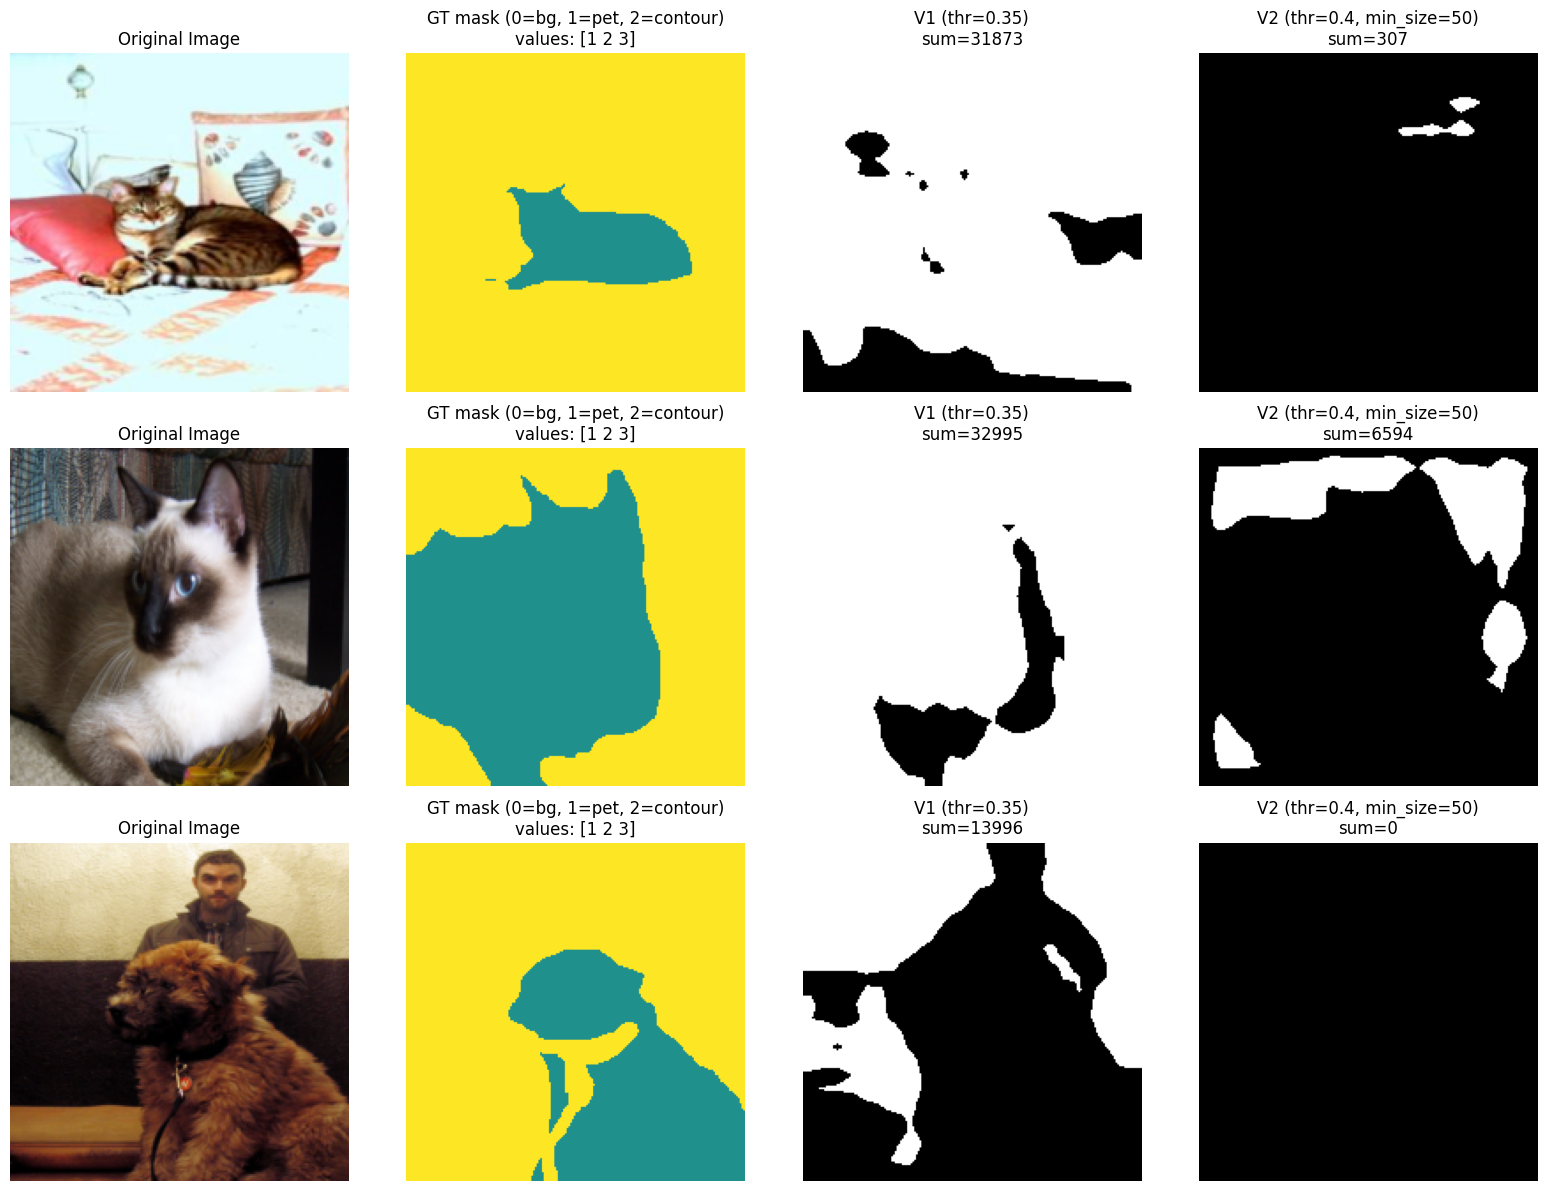

In [60]:
def visualize_segmentation_results(model, dataloader, device, num_samples=3):
    """Визуализация с правильными классами OxfordPet"""
    model.eval()
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, 4*num_samples))

    if num_samples == 1:
        axes = axes.reshape(1, -1)

    with torch.no_grad():
        for i, (images, targets) in enumerate(dataloader):
            if i >= num_samples:
                break

            images = images.to(device)
            outputs = model(images)['out']

            # Берем первое изображение из батча
            img = images[0].cpu()
            target = targets[0].cpu()

            # Денормализация
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
            img_denorm = img * std + mean
            img_np = img_denorm.permute(1, 2, 0).clamp(0, 1).numpy()

            # Оригинал
            axes[i, 0].imshow(img_np)
            axes[i, 0].set_title('Original Image')
            axes[i, 0].axis('off')

            # GT маска
            if target.dim() == 3:
                gt_mask = target.squeeze(0).numpy()
            else:
                gt_mask = target.numpy()

            # Показываем сырую маску (0,1,2)
            axes[i, 1].imshow(gt_mask, cmap='viridis', vmin=0, vmax=2)
            axes[i, 1].set_title(f'GT mask (0=bg, 1=pet, 2=contour)\nvalues: {np.unique(gt_mask)}')
            axes[i, 1].axis('off')

            # V1 предсказание
            pred_v1 = postprocess_mask_v1(outputs[0].cpu())
            if pred_v1.dim() == 3:
                pred_v1 = pred_v1[0]
            axes[i, 2].imshow(pred_v1.numpy(), cmap='gray', vmin=0, vmax=1)
            axes[i, 2].set_title(f'V1 (thr=0.35)\nsum={pred_v1.sum().item():.0f}')
            axes[i, 2].axis('off')

            # V2 предсказание
            pred_v2 = postprocess_mask_v2(outputs[0].cpu())
            if pred_v2.dim() == 3:
                pred_v2 = pred_v2[0]
            axes[i, 3].imshow(pred_v2.numpy(), cmap='gray', vmin=0, vmax=1)
            axes[i, 3].set_title(f'V2 (thr=0.4, min_size=50)\nsum={pred_v2.sum().item():.0f}')
            axes[i, 3].axis('off')

    plt.tight_layout()
    os.makedirs('artifacts/figures', exist_ok=True)
    plt.savefig('artifacts/figures/segmentation_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

# Вызов визуализации
visualize_segmentation_results(model_seg, val_loader_pet, DEVICE, num_samples=3)

## 3.7. График метрик (для artifacts/figures/segmentation_metrics.png)

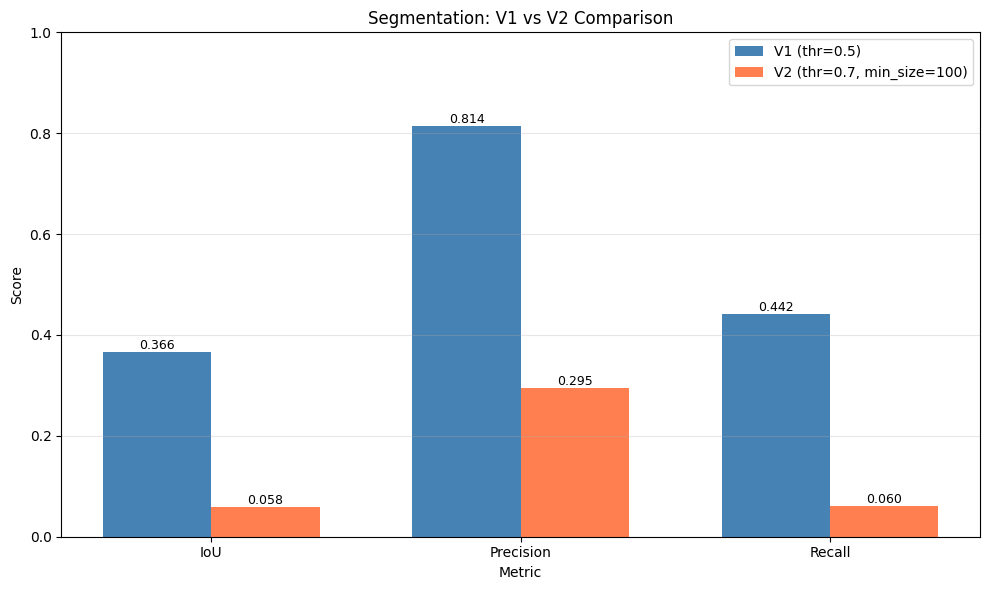

V1 values: [0.36571724340591305, 0.8140825323790682, 0.4416890808580886]
V2 values: [0.05836265990252395, 0.2945922443982792, 0.0604750775666414]


In [55]:
def plot_segmentation_metrics(metrics_v1, metrics_v2):
    """Строит сравнение метрик для V1 и V2 с проверкой наличия данных"""

    # Проверка, что метрики - словари с нужными ключами
    if not isinstance(metrics_v1, dict):
        print(f"Ошибка: metrics_v1 не словарь, а {type(metrics_v1)}")
        metrics_v1 = {'mean_iou': 0, 'mean_precision': 0, 'mean_recall': 0}

    if not isinstance(metrics_v2, dict):
        print(f"Ошибка: metrics_v2 не словарь, а {type(metrics_v2)}")
        metrics_v2 = {'mean_iou': 0, 'mean_precision': 0, 'mean_recall': 0}

    labels = ['IoU', 'Precision', 'Recall']

    # Безопасное извлечение значений
    v1_values = [
        metrics_v1.get('mean_iou', 0),
        metrics_v1.get('mean_precision', 0),
        metrics_v1.get('mean_recall', 0)
    ]
    v2_values = [
        metrics_v2.get('mean_iou', 0),
        metrics_v2.get('mean_precision', 0),
        metrics_v2.get('mean_recall', 0)
    ]

    x = np.arange(len(labels))
    width = 0.35

    plt.figure(figsize=(10, 6))
    bars1 = plt.bar(x - width/2, v1_values, width, label='V1 (thr=0.5)', color='steelblue')
    bars2 = plt.bar(x + width/2, v2_values, width, label='V2 (thr=0.7, min_size=100)', color='coral')

    # Добавляем значения
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                plt.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom', fontsize=9)

    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.title('Segmentation: V1 vs V2 Comparison')
    plt.xticks(x, labels)
    plt.ylim(0, 1.0)
    plt.legend()
    plt.grid(True, axis='y', alpha=0.3)

    plt.tight_layout()
    os.makedirs('artifacts/figures', exist_ok=True)
    plt.savefig('artifacts/figures/segmentation_metrics.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Вывод значений для проверки
    print(f"V1 values: {v1_values}")
    print(f"V2 values: {v2_values}")

# Проверка наличия переменных перед вызовом
if 'metrics_v1' not in dir() or 'metrics_v2' not in dir():
    print("ВНИМАНИЕ: metrics_v1 или metrics_v2 не определены. Использую заглушки.")
    metrics_v1 = {'mean_iou': 0, 'mean_precision': 0, 'mean_recall': 0}
    metrics_v2 = {'mean_iou': 0, 'mean_precision': 0, 'mean_recall': 0}

plot_segmentation_metrics(metrics_v1, metrics_v2)

# 4. Сохранение результатов в runs.csv

In [61]:
import pandas as pd
from datetime import datetime

def init_runs_csv():
    os.makedirs('artifacts', exist_ok=True)

    columns = {
        'experiment_id': 'object',
        'task': 'object',
        'dataset': 'object',
        'seed': 'int64',
        'model_summary': 'object',
        'optimizer': 'object',
        'lr': 'object',
        'epochs_trained': 'int64',
        'best_val_accuracy': 'float64',
        'test_accuracy': 'float64',
        'precision': 'float64',
        'recall': 'float64',
        'mean_iou': 'float64',
        'notes': 'object'
    }

    if os.path.exists('artifacts/runs.csv'):
        return pd.read_csv('artifacts/runs.csv')
    else:
        df = pd.DataFrame({col: pd.Series(dtype=typ) for col, typ in columns.items()})
        df.to_csv('artifacts/runs.csv', index=False)
        return df

def add_run_to_csv(exp_id, task, dataset, model, optimizer, lr, epochs,
                   best_val_acc=None, test_acc=None,
                   precision=None, recall=None, mean_iou=None, notes=''):
    """Добавляет запись о эксперименте в runs.csv"""

    df = init_runs_csv()

    new_row = {
        'experiment_id': exp_id,
        'task': task,
        'dataset': dataset,
        'seed': RANDOM_STATE,
        'model_summary': model.__class__.__name__,
        'optimizer': optimizer.__class__.__name__ if optimizer else 'N/A',
        'lr': lr,
        'epochs_trained': epochs,
        'best_val_accuracy': best_val_acc if best_val_acc else '',
        'test_accuracy': test_acc if test_acc else '',
        'precision': precision if precision else '',
        'recall': recall if recall else '',
        'mean_iou': mean_iou if mean_iou else '',
        'notes': notes
    }

    df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)
    df.to_csv('artifacts/runs.csv', index=False)
    print(f"Added {exp_id} to runs.csv")

# Добавляем все эксперименты
add_run_to_csv('C1', 'classification', 'STL10', model_c1, optimizer_c1, 1e-3, EPOCHS_C1_C2,
               best_val_acc_c1, test_acc_c1, notes='simple-cnn-base')

add_run_to_csv('C2', 'classification', 'STL10', model_c2, optimizer_c2, 1e-3, EPOCHS_C1_C2,
               best_val_acc_c2, test_acc_c2, notes='simple-cnn-aug')

add_run_to_csv('C3', 'classification', 'STL10', model_c3, optimizer_c3, 1e-3, EPOCHS_C3_C4,
               best_val_acc_c3, test_acc_c3, notes='resnet18-head-only')

add_run_to_csv('C4', 'classification', 'STL10', model_c4, optimizer_c4, '1e-3/1e-4', EPOCHS_C3_C4,
               best_val_acc_c4, test_acc_c4, notes='resnet18-finetune')

add_run_to_csv('V1', 'segmentation', 'OxfordIIITPet', model_seg, None, 'N/A', 0,
               mean_iou=metrics_v1['mean_iou'], precision=metrics_v1['mean_precision'],
               recall=metrics_v1['mean_recall'], notes='threshold=0.35 (адаптированный порог)')

add_run_to_csv('V2', 'segmentation', 'OxfordIIITPet', model_seg, None, 'N/A', 0,
               mean_iou=metrics_v2['mean_iou'], precision=metrics_v2['mean_precision'],
               recall=metrics_v2['mean_recall'], notes='threshold=0.4, min_size=50')

# Показываем итоговую таблицу
print("\n" + "=" * 80)
print("Final runs.csv:")
print("=" * 80)
df = pd.read_csv('artifacts/runs.csv')
print(df.to_string())

Added C1 to runs.csv
Added C2 to runs.csv
Added C3 to runs.csv
Added C4 to runs.csv
Added V1 to runs.csv
Added V2 to runs.csv

Final runs.csv:
   experiment_id            task        dataset  seed   model_summary optimizer         lr  epochs_trained  best_val_accuracy  test_accuracy  precision    recall  mean_iou                                  notes
0             C1  classification          STL10    42  SimpleSTL10CNN      Adam      0.001               4              0.457       0.442667        NaN       NaN       NaN                        simple-cnn-base
1             C2  classification          STL10    42  SimpleSTL10CNN      Adam      0.001               4              0.449       0.478667        NaN       NaN       NaN                         simple-cnn-aug
2             C3  classification          STL10    42          ResNet      Adam      0.001               3              0.931       0.936000        NaN       NaN       NaN                     resnet18-head-only
3            